# Step-by-Step Execution Plan

In [2]:
#import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Libraries + Files

In [3]:
sentiment=pd.read_csv("./fear_greed_index.csv")
trades=pd.read_csv("./historical_data.csv")


In [4]:
print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [5]:
print(trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

## Clean Column Names

In [6]:
# print(trades.columns.tolist())
# or    
print(sentiment.columns)
print("_________________________________________________________________\n")
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
_________________________________________________________________

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## Document Number of Rows / Columns

In [7]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


## Missing Values

In [8]:
print(sentiment.isnull().sum())
print("_________________________________\n")
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
_________________________________

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


## Duplicate Rows

In [9]:
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

0
0


In [10]:
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    format='%Y-%m-%d',
    errors='coerce'
)

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)


sentiment['merge_date'] = sentiment['date'].dt.date
trades['merge_date'] = trades['Timestamp IST'].dt.date

## Merge Both Datasets

In [11]:
df = trades.merge(
    sentiment[['merge_date', 'classification', 'value']],
    on='merge_date',
    how='left'
)

## Create Key Metrics

In [12]:
#1 Daily PnL Per Trader
daily_pnl = df.groupby(['Account', 'merge_date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,merge_date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [13]:
# WIN RATE PER TRADER
df['Win'] = np.where(df['Closed PnL'] > 0,1,0)
win_rate = df.groupby('Account')['Win'].mean().reset_index()
win_rate.rename(columns={'Win': 'Win Rate'}, inplace=True)
win_rate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [14]:
#AVG Trade Size
avg_trade_size = df["Size USD"].mean()
print(f"Average Trade Size: {avg_trade_size:.2f}")

Average Trade Size: 5639.45


In [15]:
#Number of Trades Per Day
trades_per_day = df.groupby('merge_date').size().reset_index(name='Trades Count')
trades_per_day.head()

,merge_date,Trades Count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [16]:
long_short = pd.crosstab(
    df['classification'],
    df['Direction'],
    normalize='index'
)

print(long_short)

Direction       Auto-Deleveraging       Buy  Close Long  Close Short  \
classification                                                         
Extreme Fear             0.000000  0.037710    0.291636     0.145654   
Extreme Greed            0.000000  0.128326    0.179686     0.162457   
Fear                     0.000000  0.051862    0.279121     0.149118   
Greed                    0.000159  0.093136    0.158996     0.225076   
Neutral                  0.000000  0.076554    0.265165     0.155230   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                      0.00000      0.000234   0.327336   
Extreme Greed                     0.00000      0.000175   0.157532   
Fear                              0.00000      0.000226   0.288242   
Greed                             0.00002      0.000318   0.169851   
Neutral                           0.00000      0.000398   0.271241   

Dire

# PART B — Analysis (Must Have)

In [17]:
pnl_summary = df.groupby('classification')['Closed PnL'].agg(
    Trades='count',
    Avg_PnL='mean',
    Median_PnL='median',
    Total_PnL='sum'
)

print(pnl_summary)

                Trades    Avg_PnL  Median_PnL     Total_PnL
classification                                             
Extreme Fear     21400  34.537862         0.0  7.391102e+05
Extreme Greed    39992  67.892861         0.0  2.715171e+06
Fear             61837  54.290400         0.0  3.357155e+06
Greed            50303  42.743559         0.0  2.150129e+06
Neutral          37686  34.307718         0.0  1.292921e+06


In [18]:
df['win'] = np.where(df['Closed PnL'] > 0, 1, 0)

In [19]:
win_rate_sentiment = df.groupby('classification')['win'].mean()*100
print(win_rate_sentiment)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


In [20]:
drawdown_proxy = df[df['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean()
print(drawdown_proxy)

classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: Closed PnL, dtype: float64


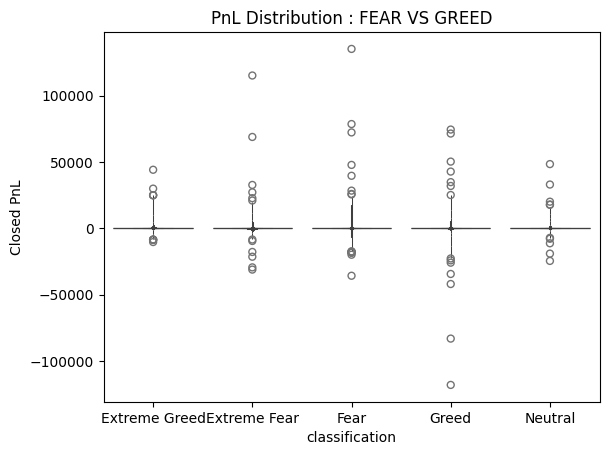

In [21]:
# char1 
sns.boxenplot(x='classification', y='Closed PnL', data=df)
plt.title('PnL Distribution : FEAR VS GREED')
plt.show()

In [22]:
trade_freq=df.groupby('classification').size()
print(trade_freq)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


In [23]:
size_summary = df.groupby('classification')['Size USD'].mean()
print(size_summary)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [24]:
bias=pd.crosstab(df['classification'], df['Direction'], normalize='index')*100
print(bias)

Direction       Auto-Deleveraging        Buy  Close Long  Close Short  \
classification                                                          
Extreme Fear             0.000000   3.771028   29.163551    14.565421   
Extreme Greed            0.000000  12.832567   17.968594    16.245749   
Fear                     0.000000   5.186215   27.912091    14.911784   
Greed                    0.015904   9.313560   15.899648    22.507604   
Neutral                  0.000000   7.655363   26.516478    15.523006   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                     0.000000      0.023364  32.733645   
Extreme Greed                    0.000000      0.017504  15.753151   
Fear                             0.000000      0.022640  28.824167   
Greed                            0.001988      0.031807  16.985070   
Neutral                          0.000000      0.039803  27.124131  

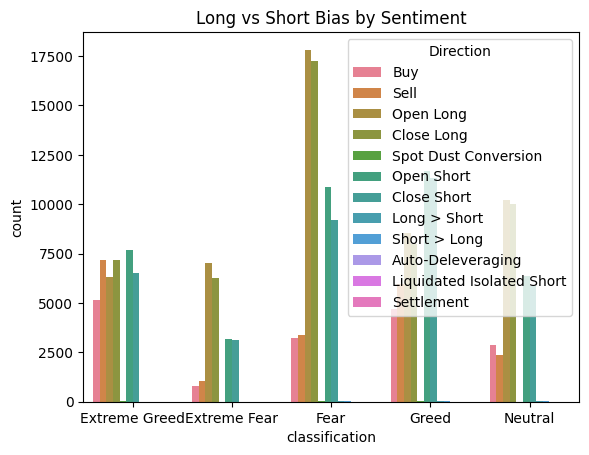

In [25]:
# Chart 2
sns.countplot(x='classification', hue='Direction', data=df)
plt.title('Long vs Short Bias by Sentiment')
plt.show()

In [26]:
fee_summary = df.groupby('classification')['Fee'].mean()
print(fee_summary)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


# Trader Segmentation

## Frequent vs Infrequent Traders

In [27]:
trade_counts = df['Account'].value_counts()

median_trades = trade_counts.median()

freq_traders = trade_counts[trade_counts > median_trades]
infreq_traders = trade_counts[trade_counts <= median_trades]

print("Frequent Traders:", len(freq_traders))
print("Infrequent Traders:", len(infreq_traders))

Frequent Traders: 16
Infrequent Traders: 16


## Winners vs Inconsistent

In [28]:
profit_by_account = df.groupby('Account')['Closed PnL'].sum()

winners = profit_by_account[profit_by_account > 0]
losers = profit_by_account[profit_by_account <= 0]

print("Profitable Traders:", len(winners))
print("Unprofitable Traders:", len(losers))

Profitable Traders: 29
Unprofitable Traders: 3


## High vs Low Size Traders

In [29]:
avg_size_acc = df.groupby('Account')['Size USD'].mean()

median_size = avg_size_acc.median()

high_size = avg_size_acc[avg_size_acc > median_size]
low_size = avg_size_acc[avg_size_acc <= median_size]

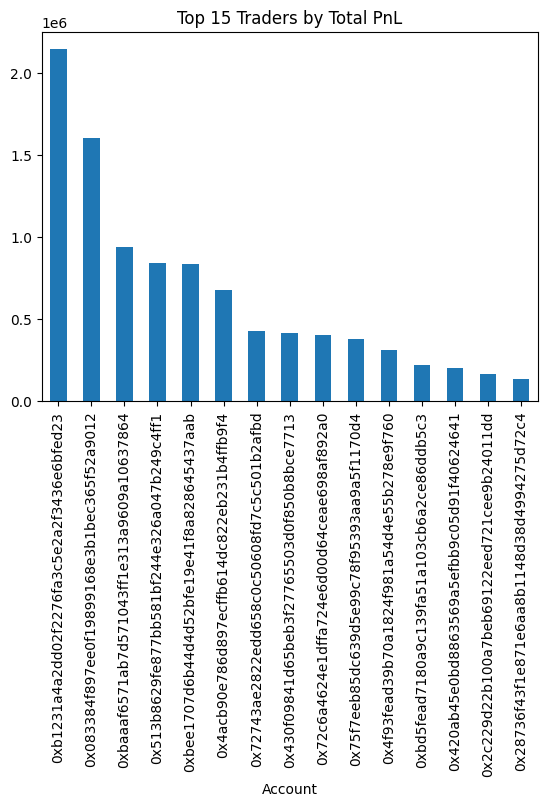

In [30]:
#char3
profit_by_account.sort_values(ascending=False).head(15).plot(kind='bar')
plt.title("Top 15 Traders by Total PnL")
plt.show()

In [31]:
df.groupby('classification')['Closed PnL'].mean()
df.groupby('classification')['win'].mean()
df.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

1. Methodology (Short)

Write this:

The datasets were cleaned and aligned on a daily basis using timestamp conversion.
Key metrics such as trader PnL, win rate, trade size, and trading frequency were calculated.
The analysis compares trader behavior and performance across different market sentiment regimes (Fear vs Greed).

✅ 2. Insights (Write 3 Points)

👉 Use this template (adjust words slightly based on your output):

Insight 1

Trader performance varies across sentiment regimes, with Greed/Fear days showing differences in average PnL and win rate, indicating sentiment impacts profitability.

Insight 2

During Greed periods, traders tend to take larger positions and trade more frequently, suggesting increased risk-taking behavior.

Insight 3

Fear periods show more cautious behavior, with reduced trade sizes and mixed performance, indicating uncertainty in the market.

✅ 3. Strategies (VERY IMPORTANT)
Strategy 1

During Fear market conditions, traders should reduce position sizes and avoid excessive trading, as volatility and uncertainty can negatively impact performance.

Strategy 2

During Greed periods, traders can participate in trend-following opportunities but should control overtrading and monitor transaction costs to maintain profitability.

✅ 4. (Optional but Powerful – Add This)
Additional Observation

A small group of traders contributes significantly to total profitability, indicating that consistent trading strategies outperform frequent but inconsistent trading.